## Regularization Implementation

Train accuracy: 55.62%
Val accuracy:   57.50%


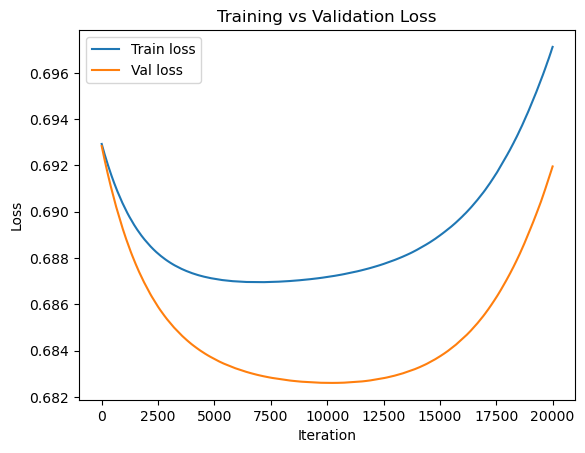

In [ ]:
# importing the libraries
import numpy as np
import matplotlib.pyplot as plt

# data
np.random.seed(42)
X = np.random.randn(200, 2)
y = (X[:, 0]**2 + X[:, 1]**2 < 1).astype(int)

# model
class NeuralNetworkDropout:
    def __init__(self, lr=0.01, n_iter=10000, 
                 keep_prob=0.8, lambda_l2=0.01):
        self.lr = lr
        self.n_iter = n_iter
        self.keep_prob = keep_prob
        self.lambda_l2 = lambda_l2
        self.loss_history = []
        self.val_loss_history = []

    def sigmoid(self, z):
        return 1 / (1 + np.exp(-z))

    def relu(self, z):
        return np.maximum(0, z)

    def relu_derivative(self, z):
        return (z > 0).astype(float)

    def initialize(self):
        self.W1 = np.random.randn(2, 32) * 0.1
        self.b1 = np.zeros(32)
        self.W2 = np.random.randn(32, 16) * 0.1
        self.b2 = np.zeros(16)
        self.W3 = np.random.randn(16, 1) * 0.1
        self.b3 = np.zeros(1)

    def forward(self, X, training=True):
        self.z1 = X @ self.W1 + self.b1
        self.a1 = self.relu(self.z1)
        if training:
            self.mask1 = np.random.binomial(
                1, self.keep_prob, self.a1.shape)
            self.a1 = self.a1 * self.mask1 / self.keep_prob

        self.z2 = self.a1 @ self.W2 + self.b2
        self.a2 = self.relu(self.z2)
        if training:
            self.mask2 = np.random.binomial(
                1, self.keep_prob, self.a2.shape)
            self.a2 = self.a2 * self.mask2 / self.keep_prob

        self.z3 = self.a2 @ self.W3 + self.b3
        self.a3 = self.sigmoid(self.z3)
        return self.a3

    def backward(self, X, y):
        n = len(y)
        delta3 = self.a3 - y.reshape(-1, 1)
        dW3 = (1/n) * self.a2.T @ delta3 + self.lambda_l2 * self.W3
        db3 = (1/n) * np.sum(delta3, axis=0)

        delta2 = delta3 @ self.W3.T * self.relu_derivative(self.z2)
        delta2 = delta2 * self.mask2 / self.keep_prob
        dW2 = (1/n) * self.a1.T @ delta2 + self.lambda_l2 * self.W2
        db2 = (1/n) * np.sum(delta2, axis=0)

        delta1 = delta2 @ self.W2.T * self.relu_derivative(self.z1)
        delta1 = delta1 * self.mask1 / self.keep_prob
        dW1 = (1/n) * X.T @ delta1 + self.lambda_l2 * self.W1
        db1 = (1/n) * np.sum(delta1, axis=0)

        self.W3 -= self.lr * dW3
        self.b3 -= self.lr * db3
        self.W2 -= self.lr * dW2
        self.b2 -= self.lr * db2
        self.W1 -= self.lr * dW1
        self.b1 -= self.lr * db1

    def fit(self, X_train, y_train, X_val, y_val):
        self.initialize()
        for _ in range(self.n_iter):
            self.forward(X_train, training=True)
            self.backward(X_train, y_train)

            train_pred = self.forward(X_train, training=False)
            train_loss = -np.mean(y_train * np.log(train_pred + 1e-8) +
                                 (1-y_train) * np.log(1-train_pred + 1e-8))
            self.loss_history.append(train_loss)

            val_pred = self.forward(X_val, training=False)
            val_loss = -np.mean(y_val * np.log(val_pred + 1e-8) +
                               (1-y_val) * np.log(1-val_pred + 1e-8))
            self.val_loss_history.append(val_loss)

# train/val split
from sklearn.model_selection import train_test_split
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42)

model = NeuralNetworkDropout(lr=0.001, n_iter=20000,
                              keep_prob=0.8, lambda_l2=0.001)
model.fit(X_train, y_train, X_val, y_val)

# results
train_pred = model.forward(X_train, training=False)
val_pred = model.forward(X_val, training=False)
train_acc = np.mean((train_pred >= 0.5).astype(int).flatten() == y_train)
val_acc = np.mean((val_pred >= 0.5).astype(int).flatten() == y_val)
print(f"Train accuracy: {train_acc*100:.2f}%")
print(f"Val accuracy:   {val_acc*100:.2f}%")

# plot
plt.plot(model.loss_history, label='Train loss')
plt.plot(model.val_loss_history, label='Val loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.legend()
plt.show()